# Auditoria de Dados - MC859

Este notebook reproduz a auditoria do dataset da Steam a partir dos arquivos brutos em `data/raw/`.

Objetivos:

- inspecionar a estrutura real dos arquivos
- mapear entidades e chaves
- verificar consistência entre arquivos
- medir distribuições relevantes para os grafos
- justificar as conclusões do relatório em `00_data_audit_report.md`

Observação: algumas células fazem varredura completa de arquivos grandes, especialmente `recommendations.csv`. Elas podem levar alguns minutos para executar.

In [26]:
from __future__ import annotations

import csv
import json
import math
import re
import subprocess
from collections import Counter
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False


BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

RAW_DIR = BASE_DIR / 'data' / 'raw'
REPORT_PATH = BASE_DIR / 'notebooks' / '00_data_audit_report.md'

DATE_RE = re.compile(r'^\d{4}-\d{2}-\d{2}$')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

RAW_DIR

PosixPath('/home/guilherme/mc859/data/raw')

In [27]:
def infer_value_type(value):
    if value is None:
        return None
    if isinstance(value, list):
        return 'list'
    if isinstance(value, dict):
        return 'dict'
    if isinstance(value, bool):
        return 'bool'
    if isinstance(value, int) and not isinstance(value, bool):
        return 'int'
    if isinstance(value, float):
        return 'float'
    s = str(value).strip()
    if s == '':
        return None
    low = s.lower()
    if low in {'true', 'false'}:
        return 'bool'
    if DATE_RE.match(s):
        return 'date'
    if s.isdigit() or (s.startswith('-') and s[1:].isdigit()):
        return 'int'
    try:
        float(s)
        return 'float'
    except ValueError:
        return 'string'


def merge_types(current, new):
    if new is None:
        return current
    if current is None:
        return new
    if current == new:
        return current
    if {current, new} == {'int', 'float'}:
        return 'float'
    return 'string'


def count_physical_lines(path: Path) -> int:
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for _ in f)


def percentile_from_sorted(values, p):
    if not values:
        return None
    idx = min(len(values) - 1, max(0, math.ceil(p * len(values)) - 1))
    return values[idx]


def summarize_counter(counter: Counter) -> dict:
    values = sorted(counter.values())
    return {
        'count': len(values),
        'min': values[0] if values else None,
        'p50': percentile_from_sorted(values, 0.50),
        'p75': percentile_from_sorted(values, 0.75),
        'p90': percentile_from_sorted(values, 0.90),
        'p95': percentile_from_sorted(values, 0.95),
        'p99': percentile_from_sorted(values, 0.99),
        'max': values[-1] if values else None,
        'mean': (sum(values) / len(values)) if values else None,
    }


def as_table(mapping: dict, left='campo', right='valor'):
    return pd.DataFrame([{left: k, right: v} for k, v in mapping.items()])


In [28]:
def summarize_csv_stream(path: Path, count_unique_for=None, collect_unique_app=False, count_app_freq=False):
    count_unique_for = count_unique_for or []
    physical_lines = count_physical_lines(path)

    with path.open('r', encoding='utf-8', newline='') as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        nulls = {c: 0 for c in columns}
        inferred_types = {c: None for c in columns}
        samples = []
        unique_values = {c: set() for c in count_unique_for}
        unique_app_ids = set() if collect_unique_app else None
        app_counter = Counter() if count_app_freq else None
        rows = 0

        for row in reader:
            rows += 1
            if len(samples) < 3:
                samples.append(row.copy())

            for col in columns:
                value = row[col]
                if value == '':
                    nulls[col] += 1
                inferred_types[col] = merge_types(inferred_types[col], infer_value_type(value))
                if col in unique_values:
                    unique_values[col].add(value)

            if unique_app_ids is not None and row.get('app_id'):
                unique_app_ids.add(int(row['app_id']))

            if app_counter is not None and row.get('app_id'):
                app_counter[int(row['app_id'])] += 1

    result = {
        'file': path.name,
        'physical_lines': physical_lines,
        'rows': rows,
        'columns': columns,
        'inferred_types': inferred_types,
        'nulls': nulls,
        'sample_records': samples,
    }

    if unique_values:
        result['nunique'] = {c: len(v) for c, v in unique_values.items()}
    if unique_app_ids is not None:
        result['unique_app_ids'] = len(unique_app_ids)
        result['app_id_set'] = unique_app_ids
    if app_counter is not None:
        result['app_counter'] = app_counter
        result['interactions_per_game'] = summarize_counter(app_counter)

    return result


def summarize_metadata_jsonl(path: Path):
    physical_lines = count_physical_lines(path)
    rows = 0
    columns = None
    inferred_types = None
    nulls = None
    samples = []
    app_ids = set()
    unique_tags = set()
    tag_counts = []
    empty_descriptions = 0

    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)

            if columns is None:
                columns = list(obj.keys())
                inferred_types = {c: None for c in columns}
                nulls = {c: 0 for c in columns}

            rows += 1
            if len(samples) < 3:
                samples.append(obj)

            for col in columns:
                value = obj.get(col)
                if value is None:
                    nulls[col] += 1
                inferred_types[col] = merge_types(inferred_types[col], infer_value_type(value))

            app_ids.add(int(obj['app_id']))

            description = obj.get('description', '')
            if description == '':
                empty_descriptions += 1

            tags = obj.get('tags', [])
            tag_counts.append(len(tags) if isinstance(tags, list) else None)
            if isinstance(tags, list):
                unique_tags.update(tags)

    sorted_tag_counts = sorted(v for v in tag_counts if v is not None)

    return {
        'file': path.name,
        'physical_lines': physical_lines,
        'rows': rows,
        'columns': columns,
        'inferred_types': inferred_types,
        'nulls': nulls,
        'sample_records': samples,
        'unique_app_ids': len(app_ids),
        'app_id_set': app_ids,
        'unique_tags': len(unique_tags),
        'all_tags': sorted(unique_tags),
        'empty_descriptions': empty_descriptions,
        'tag_counts': sorted_tag_counts,
        'tags_per_game': {
            'count': len(sorted_tag_counts),
            'min': sorted_tag_counts[0] if sorted_tag_counts else None,
            'p50': percentile_from_sorted(sorted_tag_counts, 0.50),
            'p75': percentile_from_sorted(sorted_tag_counts, 0.75),
            'p90': percentile_from_sorted(sorted_tag_counts, 0.90),
            'p95': percentile_from_sorted(sorted_tag_counts, 0.95),
            'p99': percentile_from_sorted(sorted_tag_counts, 0.99),
            'max': sorted_tag_counts[-1] if sorted_tag_counts else None,
            'mean': (sum(sorted_tag_counts) / len(sorted_tag_counts)) if sorted_tag_counts else None,
            'games_with_0_tags': sum(1 for v in sorted_tag_counts if v == 0),
            'games_with_1_2_tags': sum(1 for v in sorted_tag_counts if 1 <= v <= 2),
            'games_with_3_5_tags': sum(1 for v in sorted_tag_counts if 3 <= v <= 5),
            'games_with_6_10_tags': sum(1 for v in sorted_tag_counts if 6 <= v <= 10),
            'games_with_gt_10_tags': sum(1 for v in sorted_tag_counts if v > 10),
        },
    }


## PASSO 1 - Inspeção dos arquivos

Nesta etapa fazemos a leitura dos quatro arquivos e extraímos:

- número de linhas físicas e registros
- colunas
- tipos inferidos
- valores nulos por coluna
- exemplos de registros

In [29]:
games_summary = summarize_csv_stream(
    RAW_DIR / 'games.csv',
    count_unique_for=['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck'],
    collect_unique_app=True,
)

users_summary = summarize_csv_stream(RAW_DIR / 'users.csv')

recommendations_summary = summarize_csv_stream(
    RAW_DIR / 'recommendations.csv',
    collect_unique_app=True,
    count_app_freq=True,
)

metadata_summary = summarize_metadata_jsonl(RAW_DIR / 'games_metadata.json')

In [30]:
file_summaries = {
    'games.csv': games_summary,
    'games_metadata.json': metadata_summary,
    'users.csv': users_summary,
    'recommendations.csv': recommendations_summary,
}

for name, summary in file_summaries.items():
    display(Markdown(f"### {name}"))
    display(pd.DataFrame([{
        'linhas_fisicas': summary['physical_lines'],
        'registros': summary['rows'],
        'colunas': len(summary['columns']),
    }]))
    display(Markdown('**Tipos inferidos**'))
    display(as_table(summary['inferred_types'], 'coluna', 'tipo'))
    display(Markdown('**Nulos por coluna**'))
    display(as_table(summary['nulls'], 'coluna', 'nulos'))
    display(Markdown('**Exemplos de registros**'))
    display(pd.DataFrame(summary['sample_records']))


### games.csv

,linhas_fisicas,registros,colunas
0,50873,50872,13


**Tipos inferidos**

,coluna,tipo
0,app_id,int
1,title,string
2,date_release,date
3,win,bool
4,mac,bool
5,linux,bool
6,rating,string
7,positive_ratio,int
8,user_reviews,int
9,price_final,float


**Nulos por coluna**

...

,coluna,tipo
0,app_id,int
1,helpful,int
2,funny,int
3,date,date
4,is_recommended,bool
5,hours,float
6,user_id,int
7,review_id,int


**Nulos por coluna**

,coluna,nulos
0,app_id,0
1,helpful,0
2,funny,0
3,date,0
4,is_recommended,0
5,hours,0
6,user_id,0
7,review_id,0


**Exemplos de registros**

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,true,36.3,51580,0
1,304390,4,0,2017-02-17,false,11.5,2586,1
2,1085660,2,0,2019-11-17,true,336.5,253880,2


## PASSO 2 e 3 - Mapeamento das entidades e relações entre arquivos

Agora verificamos explicitamente quais colunas representam as entidades principais e se o `app_id` é consistente entre catálogo, metadados e interações.

In [31]:
games_ids = games_summary['app_id_set']
metadata_ids = metadata_summary['app_id_set']
recommendation_game_ids = recommendations_summary['app_id_set']

relation_table = pd.DataFrame([
    {'medida': 'games.csv', 'jogos_distintos': len(games_ids)},
    {'medida': 'games_metadata.json', 'jogos_distintos': len(metadata_ids)},
    {'medida': 'recommendations.csv', 'jogos_distintos': len(recommendation_game_ids)},
    {'medida': 'games ∩ metadata', 'jogos_distintos': len(games_ids & metadata_ids)},
    {'medida': 'games ∩ recommendations', 'jogos_distintos': len(games_ids & recommendation_game_ids)},
    {'medida': 'metadata ∩ recommendations', 'jogos_distintos': len(metadata_ids & recommendation_game_ids)},
    {'medida': 'interseção dos três', 'jogos_distintos': len(games_ids & metadata_ids & recommendation_game_ids)},
    {'medida': 'recommendations sem metadata', 'jogos_distintos': len(recommendation_game_ids - metadata_ids)},
    {'medida': 'metadata sem recommendations', 'jogos_distintos': len(metadata_ids - recommendation_game_ids)},
])

display(relation_table)

print('Exemplos de jogos em metadata mas não em recommendations:')
print(sorted(metadata_ids - recommendation_game_ids)[:20])

print('\nMapeamento das entidades observado:')
print('- ID de jogo: app_id, presente em games.csv, games_metadata.json e recommendations.csv')
print('- ID de usuário: user_id, presente em users.csv e recommendations.csv')
print('- Tags: campo tags em games_metadata.json, estruturado como lista de strings')

,medida,jogos_distintos
0,games.csv,50872
1,games_metadata.json,50872
2,recommendations.csv,37610
3,games ∩ metadata,50872
4,games ∩ recommendations,37610
5,metadata ∩ recommendations,37610
6,interseção dos três,37610
7,recommendations sem metadata,0
8,metadata sem recommendations,13262


Exemplos de jogos em metadata mas não em recommendations:
[360, 1230, 1256, 1257, 1280, 1840, 3838, 4230, 4780, 4856, 8340, 8990, 10195, 10196, 10600, 10604, 10606, 10607, 10608, 10695]

Mapeamento das entidades observado:
- ID de jogo: app_id, presente em games.csv, games_metadata.json e recommendations.csv
- ID de usuário: user_id, presente em users.csv e recommendations.csv
- Tags: campo tags em games_metadata.json, estruturado como lista de strings


In [32]:
def user_overlap_via_sort(raw_dir: Path):
    with TemporaryDirectory() as tmp_dir_name:
        tmp_dir = Path(tmp_dir_name)
        rec_ids_raw = tmp_dir / 'recs_user_ids.txt'
        users_ids_raw = tmp_dir / 'users_user_ids.txt'

        with (raw_dir / 'recommendations.csv').open('r', encoding='utf-8', newline='') as f_in, rec_ids_raw.open('w', encoding='utf-8') as f_out:
            reader = csv.DictReader(f_in)
            for row in reader:
                f_out.write(row['user_id'] + '\n')

        with (raw_dir / 'users.csv').open('r', encoding='utf-8', newline='') as f_in, users_ids_raw.open('w', encoding='utf-8') as f_out:
            reader = csv.DictReader(f_in)
            for row in reader:
                f_out.write(row['user_id'] + '\n')

        rec_sorted = tmp_dir / 'recs_user_ids_sorted.txt'
        users_sorted = tmp_dir / 'users_user_ids_sorted.txt'

        subprocess.run(['sort', '-u', str(rec_ids_raw), '-o', str(rec_sorted)], check=True)
        subprocess.run(['sort', '-u', str(users_ids_raw), '-o', str(users_sorted)], check=True)

        rec_unique = int(subprocess.check_output(['wc', '-l', str(rec_sorted)]).decode().strip().split()[0])
        users_unique = int(subprocess.check_output(['wc', '-l', str(users_sorted)]).decode().strip().split()[0])
        overlap = int(subprocess.check_output(['bash', '-lc', f"comm -12 '{rec_sorted}' '{users_sorted}' | wc -l"]).decode().strip())
        rec_not_users = int(subprocess.check_output(['bash', '-lc', f"comm -23 '{rec_sorted}' '{users_sorted}' | wc -l"]).decode().strip())
        users_not_rec = int(subprocess.check_output(['bash', '-lc', f"comm -13 '{rec_sorted}' '{users_sorted}' | wc -l"]).decode().strip())

        return {
            'usuarios_distintos_em_recommendations': rec_unique,
            'usuarios_distintos_em_users': users_unique,
            'intersecao': overlap,
            'recommendations_sem_users': rec_not_users,
            'users_sem_recommendations': users_not_rec,
        }


users_zero_reviews = 0
users_positive_reviews = 0
products_sum = 0
reviews_sum = 0

with (RAW_DIR / 'users.csv').open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        reviews = int(row['reviews'])
        products_sum += int(row['products'])
        reviews_sum += reviews
        if reviews == 0:
            users_zero_reviews += 1
        else:
            users_positive_reviews += 1

user_overlap = user_overlap_via_sort(RAW_DIR)
users_utility_df = pd.DataFrame([{**user_overlap,
    'usuarios_com_reviews_0_em_users': users_zero_reviews,
    'usuarios_com_reviews_maior_que_0_em_users': users_positive_reviews,
    'soma_products': products_sum,
    'soma_reviews': reviews_sum,
}])

users_utility_df

,usuarios_distintos_em_recommendations,usuarios_distintos_em_users,intersecao,recommendations_sem_users,users_sem_recommendations,usuarios_com_reviews_0_em_users,usuarios_com_reviews_maior_que_0_em_users,soma_products,soma_reviews
0,13781059,14306064,13781059,0,525005,525005,13781059,1664845205,41154794


## PASSO 4 e 5 - Validação para o projeto e distribuições

As duas fontes estruturais para os grafos são:

- `games_metadata.json` para o bipartido jogo-tag
- `recommendations.csv` para o bipartido usuário-jogo

Nesta seção medimos a distribuição de interações por jogo e a distribuição do número de tags por jogo.

In [33]:
app_counter = recommendations_summary['app_counter']
interaction_values = sorted(app_counter.values())
tag_counts = metadata_summary['tag_counts']

interactions_df = pd.DataFrame([
    {'metrica': 'jogos com interações', 'valor': len(interaction_values)},
    {'metrica': 'mínimo', 'valor': interaction_values[0]},
    {'metrica': 'mediana', 'valor': percentile_from_sorted(interaction_values, 0.50)},
    {'metrica': 'p75', 'valor': percentile_from_sorted(interaction_values, 0.75)},
    {'metrica': 'p90', 'valor': percentile_from_sorted(interaction_values, 0.90)},
    {'metrica': 'p95', 'valor': percentile_from_sorted(interaction_values, 0.95)},
    {'metrica': 'p99', 'valor': percentile_from_sorted(interaction_values, 0.99)},
    {'metrica': 'máximo', 'valor': interaction_values[-1]},
    {'metrica': 'média', 'valor': round(sum(interaction_values) / len(interaction_values), 2)},
    {'metrica': 'jogos com 1 interação', 'valor': sum(1 for v in interaction_values if v == 1)},
    {'metrica': 'jogos com até 5 interações', 'valor': sum(1 for v in interaction_values if v <= 5)},
    {'metrica': 'jogos com até 10 interações', 'valor': sum(1 for v in interaction_values if v <= 10)},
    {'metrica': 'jogos com 100 ou mais interações', 'valor': sum(1 for v in interaction_values if v >= 100)},
    {'metrica': 'jogos com 1.000 ou mais interações', 'valor': sum(1 for v in interaction_values if v >= 1000)},
    {'metrica': 'jogos com 10.000 ou mais interações', 'valor': sum(1 for v in interaction_values if v >= 10000)},
])

tags_df = pd.DataFrame([
    {'metrica': 'jogos em metadata', 'valor': len(tag_counts)},
    {'metrica': 'tags distintas', 'valor': metadata_summary['unique_tags']},
    {'metrica': 'mínimo', 'valor': tag_counts[0]},
    {'metrica': 'mediana', 'valor': percentile_from_sorted(tag_counts, 0.50)},
    {'metrica': 'p75', 'valor': percentile_from_sorted(tag_counts, 0.75)},
    {'metrica': 'p90', 'valor': percentile_from_sorted(tag_counts, 0.90)},
    {'metrica': 'p95', 'valor': percentile_from_sorted(tag_counts, 0.95)},
    {'metrica': 'p99', 'valor': percentile_from_sorted(tag_counts, 0.99)},
    {'metrica': 'máximo', 'valor': tag_counts[-1]},
    {'metrica': 'média', 'valor': round(sum(tag_counts) / len(tag_counts), 2)},
    {'metrica': 'jogos com 0 tags', 'valor': sum(1 for v in tag_counts if v == 0)},
    {'metrica': 'jogos com 1-2 tags', 'valor': sum(1 for v in tag_counts if 1 <= v <= 2)},
    {'metrica': 'jogos com 3-5 tags', 'valor': sum(1 for v in tag_counts if 3 <= v <= 5)},
    {'metrica': 'jogos com 6-10 tags', 'valor': sum(1 for v in tag_counts if 6 <= v <= 10)},
    {'metrica': 'jogos com mais de 10 tags', 'valor': sum(1 for v in tag_counts if v > 10)},
])

display(Markdown('### Distribuição de interações por jogo'))
display(interactions_df)

display(Markdown('### Top 10 jogos por número de interações'))
display(pd.DataFrame([
    {'app_id': app_id, 'interacoes': count}
    for app_id, count in app_counter.most_common(10)
]))

display(Markdown('### Distribuição do número de tags por jogo'))
display(tags_df)

print(f"Descrições vazias em metadata: {metadata_summary['empty_descriptions']}")
print('Observação importante: o teto de 20 tags por jogo sugere truncamento no campo tags.')

### Distribuição de interações por jogo

,metrica,valor
0,jogos com interações,37610.00
1,mínimo,1.00
2,mediana,39.00
3,p75,180.00
4,p90,969.00
5,p95,2889.00
6,p99,23477.00
7,máximo,319492.00
8,média,1094.25
9,jogos com 1 interação,291.00


### Top 10 jogos por número de interações

,app_id,interacoes
0,440,319492
1,252490,270684
2,1091500,226414
3,730,219737
4,570,216914
5,444090,204176
6,292030,204166
7,377160,196789
8,374320,190157
9,431960,190129


### Distribuição do número de tags por jogo

,metrica,valor
0,jogos em metadata,50872.00
1,tags distintas,441.00
2,mínimo,0.00
3,mediana,11.00
4,p75,20.00
5,p90,20.00
6,p95,20.00
7,p99,20.00
8,máximo,20.00
9,média,11.48


Descrições vazias em metadata: 10373
Observação importante: o teto de 20 tags por jogo sugere truncamento no campo tags.


### Lista completa de todas as tags disponíveis

A seguir, listamos todas as tags únicas encontradas no dataset `games_metadata.json`.

In [34]:
all_tags = metadata_summary['all_tags']

print(f"Total de tags distintas: {len(all_tags)}\n")
print("=" * 80)
print("Lista de todas as tags:")
print("=" * 80)

# Exibe uma tag por linha para facilitar a cópia
for tag in all_tags:
    print(tag)

Total de tags distintas: 441

Lista de todas as tags:
1980s
1990's
2.5D
2D
2D Fighter
2D Platformer
360 Video
3D
3D Fighter
3D Platformer
3D Vision
4 Player Local
4X
6DOF
8-bit Music
ATV
Abstract
Action
Action RPG
Action RTS
Action Roguelike
Action-Adventure
Addictive
Adventure
Agriculture
Aliens
Alternate History
Ambient
America
Animation & Modeling
Anime
Arcade
Archery
Arena Shooter
Artificial Intelligence
Assassin
Asymmetric VR
Asynchronous Multiplayer
Atmospheric
Audio Production
Auto Battler
Automation
Automobile Sim
BMX
Base Building
Baseball
Based On A Novel
Basketball
Battle Royale
Beat 'em up
Beautiful
Benchmark
Bikes
Blood
Board Game
Boss Rush
Bowling
Boxing
Building
Bullet Hell
Bullet Time
CRPG
Capitalism
Card Battler
Card Game
Cartoon
Cartoony
Casual
Cats
Character Action Game
Character Customization
Chess
Choices Matter
Choose Your Own Adventure
Cinematic
City Builder
Class-Based
Classic
Clicker
Co-op
Co-op Campaign
Coding
Cold War
Collectathon
Colony Sim
Colorful
Combat
C

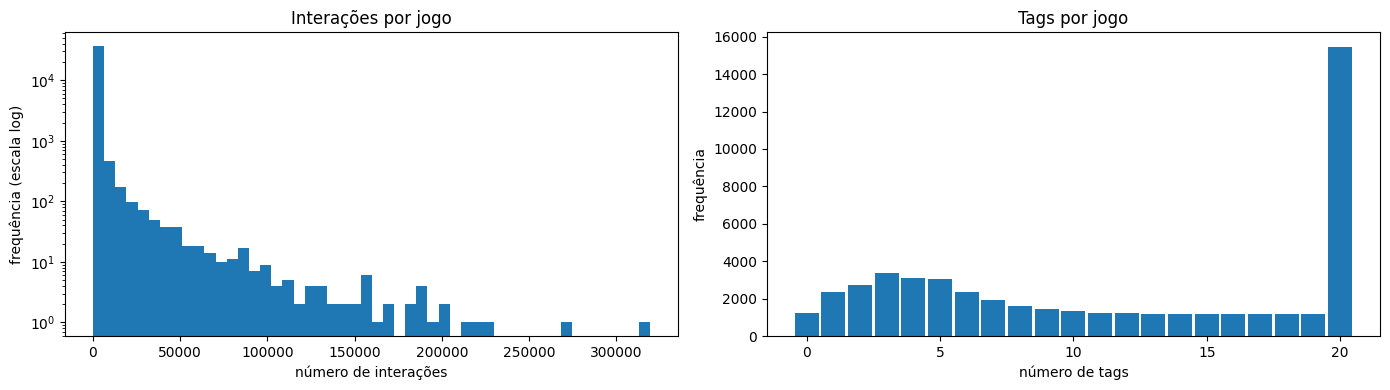

In [35]:
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(interaction_values, bins=50, log=True)
    axes[0].set_title('Interações por jogo')
    axes[0].set_xlabel('número de interações')
    axes[0].set_ylabel('frequência (escala log)')

    axes[1].hist(tag_counts, bins=range(0, 22), align='left', rwidth=0.9)
    axes[1].set_title('Tags por jogo')
    axes[1].set_xlabel('número de tags')
    axes[1].set_ylabel('frequência')
    plt.tight_layout()
else:
    print('matplotlib não está disponível neste ambiente; as tabelas acima já contêm as distribuições principais.')

## PASSO 6 e 7 - Viabilidade computacional e avaliação do dataset

A análise abaixo estima o tamanho dos grafos e o risco de explosão de arestas nas projeções jogo-jogo.

In [36]:
catalog_games = len(metadata_ids)
community_games = len(recommendation_game_ids)

catalog_game_game_upper_bound = math.comb(catalog_games, 2)
community_game_game_upper_bound = math.comb(community_games, 2)

reviews_choose2_sum = 0
with (RAW_DIR / 'users.csv').open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        reviews = int(row['reviews'])
        reviews_choose2_sum += reviews * (reviews - 1) // 2

viability_df = pd.DataFrame([
    {'medida': 'nós no bipartido jogo-tag', 'valor': catalog_games + metadata_summary['unique_tags']},
    {'medida': 'arestas jogo-tag', 'valor': sum(tag_counts)},
    {'medida': 'nós no bipartido usuário-jogo', 'valor': user_overlap['usuarios_distintos_em_recommendations'] + community_games},
    {'medida': 'arestas usuário-jogo', 'valor': recommendations_summary['rows']},
    {'medida': 'limite teórico projeção jogo-jogo por tags', 'valor': catalog_game_game_upper_bound},
    {'medida': 'limite teórico projeção jogo-jogo por usuários', 'valor': community_game_game_upper_bound},
    {'medida': 'soma de pares induzidos por usuário (choose2 dos reviews)', 'valor': reviews_choose2_sum},
])

display(viability_df)

recommended_filters = pd.DataFrame([
    {'filtro': 'mínimo de interações por jogo', 'valor_sugerido': 10, 'justificativa': 'remove a cauda muito fraca do grafo comunidade'},
    {'filtro': 'mínimo de usuários em comum por aresta jogo-jogo', 'valor_sugerido': '3 a 5', 'justificativa': 'reduz coocorrências espúrias'},
    {'filtro': 'limite de tags por jogo', 'valor_sugerido': 20, 'justificativa': 'o dataset já aparenta impor esse teto'},
])

display(Markdown('### Filtros recomendados'))
display(recommended_filters)

,medida,valor
0,nós no bipartido jogo-tag,51313
1,arestas jogo-tag,584215
2,nós no bipartido usuário-jogo,13818669
3,arestas usuário-jogo,41154794
4,limite teórico projeção jogo-jogo por tags,1293954756
5,limite teórico projeção jogo-jogo por usuários,707237245
6,soma de pares induzidos por usuário (choose2 dos reviews),494973843


### Filtros recomendados

,filtro,valor_sugerido,justificativa
0,mínimo de interações por jogo,10,remove a cauda muito fraca do grafo comunidade
1,mínimo de usuários em comum por aresta jogo-jogo,3 a 5,reduz coocorrências espúrias
2,limite de tags por jogo,20,o dataset já aparenta impor esse teto


## PASSO 7.1 - Taxonomia das tags para similaridade estrutural

Classificação completa das 441 tags do dataset.

Taxonomia reproduzível em `notebooks/tag_classification.py`.

In [37]:
from collections import Counter
from tag_classification import TAG_CATEGORIES, CATEGORY_LABELS

tag_frequency = Counter()
for line in (RAW_DIR / 'games_metadata.json').open('r', encoding='utf-8'):
    obj = json.loads(line)
    tag_frequency.update(obj['tags'])

assert set(tag_frequency) == set(TAG_CATEGORIES), 'A taxonomia precisa cobrir exatamente as tags reais do dataset.'

tag_classification_df = pd.DataFrame([
    {
        'tag': tag,
        'frequency': tag_frequency[tag],
        'category_id': TAG_CATEGORIES[tag],
        'category': CATEGORY_LABELS[TAG_CATEGORIES[tag]],
    }
    for tag in sorted(tag_frequency)
]).sort_values(['category_id', 'frequency', 'tag'], ascending=[True, False, True]).reset_index(drop=True)

category_summary_df = (
    tag_classification_df.groupby(['category_id', 'category'], as_index=False)
    .agg(tags=('tag', 'count'), frequency_total=('frequency', 'sum'))
    .sort_values('category_id')
)

display(Markdown('### Resumo da classificação'))
display(category_summary_df)

display(Markdown('### Tabela completa de classificação das tags'))
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(tag_classification_df.to_string(index=False))

display(Markdown('### Tags completas por categoria'))
for category_id in sorted(CATEGORY_LABELS):
    category_name = CATEGORY_LABELS[category_id]
    tags_in_category = tag_classification_df[tag_classification_df['category_id'] == category_id]['tag'].tolist()
    print(f'\n[{category_id}] {category_name} ({len(tags_in_category)} tags)')
    for tag in tags_in_category:
        print(f'- {tag}')

selected_technical_keep = {
    '2D', '2.5D', '3D', 'First-Person', 'Third Person', 'Top-Down', 'Isometric', 'Side Scroller', 'Text-Based', 'VR'
}

keep_core = tag_classification_df[tag_classification_df['category_id'].isin([1, 2])].copy()
keep_optional_technical = tag_classification_df[tag_classification_df['tag'].isin(selected_technical_keep)].copy()
remove_default = tag_classification_df[
    tag_classification_df['category_id'].isin([4, 5])
    | ((tag_classification_df['category_id'] == 3) & ~tag_classification_df['tag'].isin(selected_technical_keep))
].copy()

display(Markdown('### Sugestão de tags a manter'))
print('\n[Manter] Núcleo estrutural (categorias 1 e 2)')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(keep_core.sort_values(['category_id', 'frequency', 'tag'], ascending=[True, False, True])[['tag', 'frequency', 'category']].to_string(index=False))

print('\n[Manter] Subconjunto técnico opcional')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(keep_optional_technical[['tag', 'frequency', 'category']].sort_values(['frequency', 'tag'], ascending=[False, True]).to_string(index=False))

display(Markdown('### Sugestão de tags a remover'))
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(remove_default.sort_values(['category_id', 'frequency', 'tag'], ascending=[True, False, True])[['tag', 'frequency', 'category']].to_string(index=False))

automatic_criteria = pd.DataFrame([
    {
        'criterio': 'Manter tags com category_id em {1, 2}',
        'efeito': 'preserva gênero e mecânica, que são o núcleo da similaridade estrutural',
    },
    {
        'criterio': 'Manter apenas um subconjunto técnico whitelist da categoria 3',
        'efeito': 'preserva perspectiva e dimensionalidade sem introduzir tags de hardware e interface',
    },
    {
        'criterio': 'Remover categorias 4 e 5 por padrão',
        'efeito': 'evita similaridade baseada em estética, marketing, setting, conteúdo sensível ou metadados promocionais',
    },
    {
        'criterio': 'Aplicar peso IDF nas tags mantidas em vez de remover tags frequentes por regra fixa',
        'efeito': 'reduz o impacto de tags muito genéricas como Action, Adventure ou Singleplayer sem perder cobertura',
    },
    {
        'criterio': 'Opcionalmente remover tags mantidas com frequência muito baixa, por exemplo < 20 jogos',
        'efeito': 'reduz ruído de tags raríssimas, mantendo a possibilidade de calibrar esse corte empiricamente',
    },
])

display(Markdown('### Critérios automáticos de filtragem'))
display(automatic_criteria)


### Resumo da classificação

,category_id,category,tags,frequency_total
0,1,Gênero principal,104,184539
1,2,Mecânica relevante,70,105049
2,3,Característica técnica,21,42020
3,4,Estilo/estética,38,74342
4,5,Irrelevante para similaridade estrutural,208,178265


### Tabela completa de classificação das tags

                              tag  frequency  category_id                                 category
                           Action      21897            1                         Gênero principal
                        Adventure      20183            1                         Gênero principal
                       Simulation      12691            1                         Gênero principal
                         Strategy      11093            1                         Gênero principal
                              RPG      10156            1                         Gênero principal
                           Puzzle       7585            1                         Gênero principal
                           Horror       4789            1                         Gênero principal
                           Arcade       4502            1                         Gênero principal
                          Shooter       4389            1                         Gênero principal
          

### Tags completas por categoria

...


[Manter] Núcleo estrutural (categorias 1 e 2)
                      tag  frequency           category
                   Action      21897   Gênero principal
                Adventure      20183   Gênero principal
               Simulation      12691   Gênero principal
                 Strategy      11093   Gênero principal
                      RPG      10156   Gênero principal
                   Puzzle       7585   Gênero principal
                   Horror       4789   Gênero principal
                   Arcade       4502   Gênero principal
                  Shooter       4389   Gênero principal
               Platformer       3998   Gênero principal
         Action-Adventure       3367   Gênero principal
                 Survival       3265   Gênero principal
             Visual Novel       3241   Gênero principal
                      FPS       3044   Gênero principal
            Point & Click       2773   Gênero principal
                   Sports       2542   Gênero principal
 

### Sugestão de tags a remover

                              tag  frequency                                 category
                       Controller       2758                   Característica técnica
                       Mouse only        411                   Característica técnica
                     Split Screen        363                   Característica técnica
                              FMV        300                   Característica técnica
                        3D Vision        287                   Característica técnica
                   Touch-Friendly        214                   Característica técnica
                          TrackIR        126                   Característica técnica
                        360 Video         56                   Característica técnica
                    Asymmetric VR         52                   Característica técnica
                    Voice Control         20                   Característica técnica
                    Steam Machine         11          

### Critérios automáticos de filtragem

,criterio,efeito
0,"Manter tags com category_id em {1, 2}","preserva gênero e mecânica, que são o núcleo da similaridade estrutural"
1,Manter apenas um subconjunto técnico whitelist da categoria 3,preserva perspectiva e dimensionalidade sem introduzir tags de hardware e interface
2,Remover categorias 4 e 5 por padrão,"evita similaridade baseada em estética, marketing, setting, conteúdo sensível ou metadados promocionais"
3,Aplicar peso IDF nas tags mantidas em vez de remover tags frequentes por regra fixa,"reduz o impacto de tags muito genéricas como Action, Adventure ou Singleplayer sem perder cobertura"
4,"Opcionalmente remover tags mantidas com frequência muito baixa, por exemplo < 20 jogos","reduz ruído de tags raríssimas, mantendo a possibilidade de calibrar esse corte empiricamente"
